In [2]:
# These are the imports we need for our analysis.
import os
import numpy as np
from collections import defaultdict
import pandas as pd

In [4]:
# STEP 1 — Read All Label Files
# Because co-occurrence is computed from raw annotations, not predictions.

LABEL_DIR = "G:/FRP 2026/AlphaDent/labels/train" # This is the directory where our label files are stored. 
#Each file corresponds to an image txt file.
NUM_CLASSES = 4 # This is the number of classes in our dataset.


image_class_sets = [] # This will hold a list of sets, where each set contains the class IDs diagnosed in that images.

for file in os.listdir(LABEL_DIR): # Iterate through each file in the label directory
    # We only want to process text files, which contain the annotations. If it's not a txt file, we skip it.
    if not file.endswith(".txt"): 
        continue

    path = os.path.join(LABEL_DIR, file) # Get the full path to the label file.
    classes_in_image = set() # This set will hold the unique class IDs that are present in the current image. 
    #We used set to avoid duplicates, since an image might have multiple annotations of the same class.

    with open(path, "r") as f: # Open the label file for reading. 
        #Each line in this file corresponds to one annotation (one instance of a class in the image).
        for line in f: # Iterate through each line in the label file.
            if line.strip() == "": # If the line is empty i.e if there are blank lines in the file, we skip it.
                continue
            class_id = int(line.split()[0]) 
            #The first element in the line is the class ID. 
            #We split the line by whitespace and take the first element, then convert it to an integer.
            classes_in_image.add(class_id)  # We add the class ID to the set of classes present in this image.

    if classes_in_image: # If the set of classes is not empty (i.e., the image has at least one annotation), 
        #we add it to our main list of image class sets.
        image_class_sets.append(classes_in_image) # After processing all lines in the file, 
        #we add the set of classes for this image to our main list.

print("Total images processed:", len(image_class_sets))
#For each image, we have a set of classes that are present in that image. 
#This will be used to build the co-occurrence matrix.
#For example, image_class_sets[0] might be {0, 2, 5} meaning that the first image contains classes 0, 2, and 5.

Total images processed: 1237


In [5]:
# STEP-02 Build Co-Occurrence Count Matrix
# count(A,B), Then we will convert to probability later.
co_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int32) 
# This will hold the count of how many times each pair of classes co-occur in the same image.
class_counts = np.zeros(NUM_CLASSES, dtype=np.int32) # This will hold the count of how many images contain each class. 
#This is needed to compute the conditional probabilities later.

for class_set in image_class_sets: # For each image's set of classes, 
    #we will update our co-occurrence matrix and class counts.
    for a in class_set: # For each class A in the set of classes for this image, we will update the counts.
        class_counts[a] += 1 # Increment the count of images that contain class A.
        for b in class_set: 
            # For each class B in the same set, we will increment the co-occurrence count for the pair (A, B).
            co_matrix[a, b] += 1 # Increment the count of images that contain both class A and class B. 
            #Note that this will also increment co_matrix[a, a], 
            # which counts how many images contain class A (which should match class_counts[a]).

print("Raw co-occurrence matrix:\n", co_matrix) # This matrix shows how many images contain each pair of classes. 
#The diagonal (co_matrix[a, a]) shows how many images contain class A, which should match class_counts[a].
print("Class counts:\n", class_counts) # This shows how many images contain each class. 
#This should match the diagonal of the co-occurrence matrix.

#What This Means ?
#class_counts[A] = how many images contain A
#co_matrix[A,B] = how many images contain both A and B

Raw co-occurrence matrix:
 [[1065  599  171  703]
 [ 599  695  150  550]
 [ 171  150  210  150]
 [ 703  550  150  846]]
Class counts:
 [1065  695  210  846]


In [7]:
# STEP-03 Convert to Conditional Probability Matrix P(B|A)
# This is our main novelty output --- > P(B∣A)=count(A)/count(A,B)​
prob_matrix = np.zeros_like(co_matrix, dtype=float)

for a in range(NUM_CLASSES): #For each class A
    if class_counts[a] > 0: #To avoid division by zero (If no images contain A, then P(B|A) is undefined, 
        #we can leave it as 0 or handle it differently)
        prob_matrix[a] = co_matrix[a] / class_counts[a]
#co_matrix[a] = [count(a,b1), count(a,b2), ..., count(a,bN)]
#class_counts[a] = count(A)
#So, prob_matrix[a] Becomes = [P(b1|a), P(b2|a), ..., P(bN|a)]
# i.e This is the main output of this analysis. It tells us, 
# for each class A (row), what is the probability of seeing class B (column) given that A is present.


print("Conditional Probability Matrix P(B|A):\n", prob_matrix) 

#Interpretation of the conditional matrix:
#Row = condition (A present)
#Column = probability of B

#Example: P(Caries | Abrasion) = 0.42

Conditional Probability Matrix P(B|A):
 [[1.         0.56244131 0.16056338 0.6600939 ]
 [0.8618705  1.         0.21582734 0.79136691]
 [0.81428571 0.71428571 1.         0.71428571]
 [0.83096927 0.6501182  0.17730496 1.        ]]


STEP 4 — Plot the Heatmap

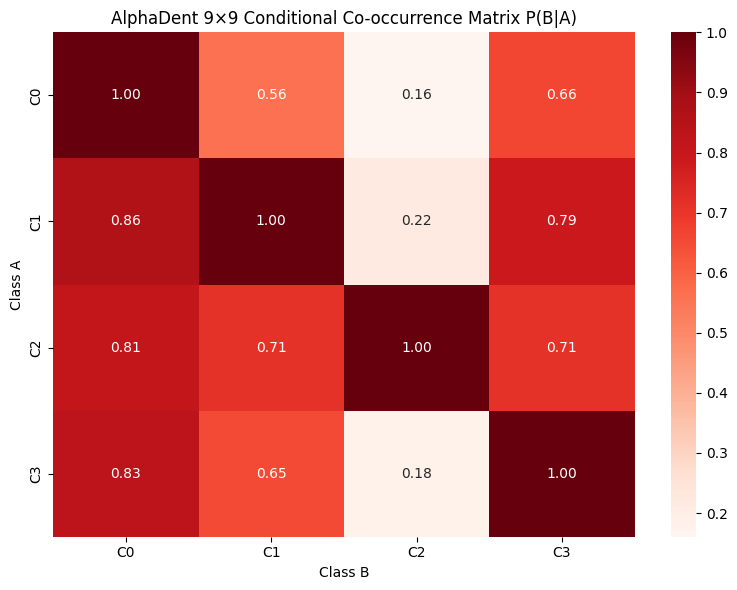

In [8]:
#This is STEP 4: Plot The Heatmap of the Conditional Co-occurrence Matrix

import matplotlib.pyplot as plt #For plotting the heatmap
import seaborn as sns #For better heatmap visualization

plt.figure(figsize=(8, 6)) #Set the figure size for better visibility of the heatmap
sns.heatmap( 
    prob_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=[f"C{i}" for i in range(NUM_CLASSES)],
    yticklabels=[f"C{i}" for i in range(NUM_CLASSES)]
) #This code uses seaborn's heatmap function to create a visual representation of the conditional probability matrix.
# annot=True means that the values will be annotated on the heatmap, 
# fmt=".2f" formats the numbers to 2 decimal places, 
# cmap="Reds" sets the color scheme, 
# and xticklabels and yticklabels label the axis with class names (C0, C1, ..., C8).


plt.title("AlphaDent 9×9 Conditional Co-occurrence Matrix P(B|A)") #Set the title of the heatmap 
plt.xlabel("Class B") #Set the label for the x-axis
plt.ylabel("Class A") #Set the label for the y-axis

plt.tight_layout() #Adjust the layout to make sure everything fits without overlap
plt.savefig("G:/FRP 2026/AlphaDent/working/co-occurrence/Figure1_Class_CoPresence_ConditionalHeatmap.png", dpi=300) 
#Save the heatmap as a high-resolution PNG file in the specified directory.
plt.show() #Display the heatmap. 
#This will show the conditional probabilities of co-occurrence between classes in a visual format,
# where higher probabilities are shown in darker red.

In [9]:
# This Step Validate the Raw Co-occurrence Counts and Find Top 5 Most Co-occurring Class Pairs Based on Raw Frequency.
pairs = [] #This will hold the pairs of classes and their co-occurrence counts, 
#which we have used to find the top 5 most co-occurring class pairs based on raw frequency Note - (this is not probability).

for a in range(NUM_CLASSES): #We use a in range to itearte through each class A
    for b in range(a + 1, NUM_CLASSES):  
        # We use b in range(a + 1, NUM_CLASSES) to ensure that we only consider unique pairs (A, B) where A < B. 
        #This avoids counting both (A, B) and (B, A) since co-occurrence is symmetric.
        pairs.append((a, b, co_matrix[a, b])) 
        #We append a tuple of (class A, class B, co-occurrence count) to the pairs list. 
        #This will allow us to sort and find the top co-occurring pairs based on raw counts.

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True) 
#We sort the pairs list in descending order based on the co-occurrence count (the third element of the tuple). 
#This will allow us to easily find the top co-occurring class pairs based on raw frequency.
top5_raw = pairs_sorted[:5] #We take the top 5 pairs from the sorted list, 
#which will be the pairs of classes that co-occur most frequently in the dataset based on raw counts (not probabilities).

df_top5 = pd.DataFrame(top5_raw,columns=["Class A", "Class B", "Raw Co-occurrence Count"]) 
#We create a pandas DataFrame from the top 5 raw co-occurring pairs, 
# with columns "Class A", "Class B", and "Raw Co-occurrence Count" for better visualization and further analysis.

print("\nTop 5 Co-occurring Class Pairs (Raw Frequency):\n") 
#We print a header to indicate that we are about to display the top 5 co-occurring class pairs based on raw frequency.
print(df_top5) 
#We print the DataFrame containing the top 5 co-occurring class pairs based on raw frequency. 
# This will show us which pairs of classes appear together most often in the images, 
# according to the raw counts from our co-occurrence matrix.

df_top5.to_csv(
    "G:/FRP 2026/AlphaDent/working/Table1_Top5_CoOccurring_ClassPairs.csv",
    index=False
)#We save the DataFrame containing the top 5 co-occurring class pairs to a CSV file in the specified directory.


Top 5 Co-occurring Class Pairs (Raw Frequency):

   Class A  Class B  Raw Co-occurrence Count
0        0        3                      703
1        0        1                      599
2        1        3                      550
3        0        2                      171
4        1        2                      150


In [10]:
# This Step Validate the Conditional Co-occurrence Probabilities and Find Top 5 Most Co-occurring Class Pairs Based on P(B|A).
pairs = []#This will hold the pairs of classes and their conditional probabilities, 
#which we will use to find the top 5 most co-occurring class pairs based on P(B|A).

for a in range(NUM_CLASSES):#We use a in range to itearte through each class A
    for b in range(NUM_CLASSES): #We use b in range to itearte through each class A
        if a != b: #We check if a and b are not the same class, 
            #because we are interested in co-occurrence between different classes. 
            # P(B|A) for the same class (A, A) would just be 1 (or 100%) since if A is present, A is present.
            pairs.append((a, b, prob_matrix[a, b]))
            #We append a tuple of (class A, class B, conditional probability P(B|A)) to the pairs list. 
            # This will allow us to sort and find the top co-occurring pairs based on conditional probability.

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True) 
#We sort the pairs list in descending order based on the conditional probability P(B|A) (the third element of the tuple). 
# This will allow us to easily find the top co-occurring class pairs based on conditional probabilities.
top5 = pairs_sorted[:5]
#We take the top 5 pairs from the sorted list, 
# which will be the pairs of classes that have the highest conditional probability of co-occurrence (P(B|A)) in the dataset.
 
df_top5 = pd.DataFrame(top5, columns=["Class A", "Class B", "P(B|A)"]) 
#We create a pandas DataFrame from the top 5 conditional co-occurring pairs, 
# with columns "Class A", "Class B", and "P(B|A)" for better visualization and further analysis.
df_top5.to_csv("G:/FRP 2026/AlphaDent/working/co-occurrence/Table1_Top5_CoOccurring_ClassPairs.csv", index=False)
#We save the DataFrame containing the top 5 co-occurring 
# class pairs based on conditional probability P(B|A) to a CSV file in the specified directory.

print(df_top5)

   Class A  Class B    P(B|A)
0        1        0  0.861871
1        3        0  0.830969
2        2        0  0.814286
3        1        3  0.791367
4        2        1  0.714286


In [11]:
# This is the Raw Matrix Validation 
print("Raw matrix shape:", co_matrix.shape)

# Check symmetry (must be TRUE for raw co-presence)
print("Raw matrix symmetric:", np.allclose(co_matrix, co_matrix.T))

# Diagonal equals class_counts?
print("Diagonal equals class_counts:",
      np.all(np.diag(co_matrix) == class_counts))

print("\nClass counts:\n", class_counts)

Raw matrix shape: (4, 4)
Raw matrix symmetric: True
Diagonal equals class_counts: True

Class counts:
 [1065  695  210  846]


In [12]:
# This is the Conditional Matrix Validation
# Diagonal must be 1 Because P(A|A) = 1
print("Conditional diagonal:", np.round(np.diag(prob_matrix), 3))

# Conditional matrix should NOT be symmetric, Because P(B|A) != P(A|B) in general
print("Conditional matrix symmetric:",
      np.allclose(prob_matrix, prob_matrix.T))

Conditional diagonal: [1. 1. 1. 1.]
Conditional matrix symmetric: False


In [13]:
# Add this at the bottom of co-occurrence.ipynb
import numpy as np

# Save the conditional probability matrix to a file
matrix_path = "G:/FRP 2026/AlphaDent/working/co_occurrence_prob_matrix.npy"
np.save(matrix_path, prob_matrix)

print(f"Conditional Probability Matrix successfully saved to {matrix_path}")

Conditional Probability Matrix successfully saved to G:/FRP 2026/AlphaDent/working/co_occurrence_prob_matrix.npy
